## 1. Obtain metadata

In [1]:
import requests
import os

url = "https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Toys_and_Games.json.gz"
file_name = "meta_Toys_and_Games.json.gz"

if not os.path.exists(file_name):
    print(f"Downloading {file_name}...")
    response = requests.get(url)
    with open(file_name, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Done!")
else:
    print(f"Already exists: {file_name}")

Done!


## 2. Build graph

In [ ]:
from src.graph_builder import build_graph

data, asin_order, le = build_graph(
    meta_path  = 'meta_Toys_and_Games.json.gz',
    cache_path = 'pyg_data_full.pt',
)

num_classes = int(data.y.max().item()) + 1

Nodes: 317329 | Edges: 7492956
Train: 222129 | Val: 47600 | Test: 47600
Classes: 18
Saved to cache: pyg_data_full.pt


Class balance analysis

In [29]:
labels = pd.Series(le.classes_)

y_series = pd.Series(data.y).value_counts()
total_nodes = data.y.shape[0]
for classes, count in zip(y_series.index, y_series):
    print(f"{labels[classes]}: {count} ({round(100*count/total_nodes,2)}%)")

Action Figures & Statues: 48875 (15.4%)
Games: 38817 (12.23%)
Stuffed Animals & Plush: 34805 (10.97%)
Hobbies: 26322 (8.29%)
Dolls & Accessories: 22150 (6.98%)
Toy Remote Control & Play Vehicles: 19678 (6.2%)
Party Supplies: 17566 (5.54%)
Arts & Crafts: 14666 (4.62%)
Sports & Outdoor Play: 14542 (4.58%)
Puzzles: 13655 (4.3%)
Learning & Education: 12541 (3.95%)
Novelty & Gag Toys: 11720 (3.69%)
Building Toys: 10116 (3.19%)
Grown-Up Toys: 9256 (2.92%)
Dress Up & Pretend Play: 9066 (2.86%)
Electronics for Kids: 6277 (1.98%)
Baby & Toddler Toys: 5145 (1.62%)
Tricycles, Scooters & Wagons: 2132 (0.67%)


## 3. Load embeddings

In [ ]:
from src.embeddings import load_image_embeddings, load_text_embeddings, combine

img = load_image_embeddings(
    parquet_path = '../gnn_embeddings/embeddings_toys_checkpoint.parquet',
    asin_order   = asin_order,
    normalize    = True,
)

X_resnet = img['resnet']
X_clip   = img['clip']
X_dino   = img['dino']

Image coverage: 317066/317329 (99.9%)
ResNet: (317329, 2048) | CLIP: (317329, 512) | DINOv2: (317329, 768)


## 4. Train

In [ ]:
from src.trainer import train


In [ ]:
val_resnet, test_resnet = train(
    data, X_resnet, in_channels=2048, num_classes=num_classes,
    model_name='SAGE+ResNet50', lr=1e-3
)

SAGE+CLIP:   0%|          | 0/300 [00:00<?, ?it/s]

Early stopping at epoch 75

Best Val Acc:  0.7075
Best Test Acc: 0.7117


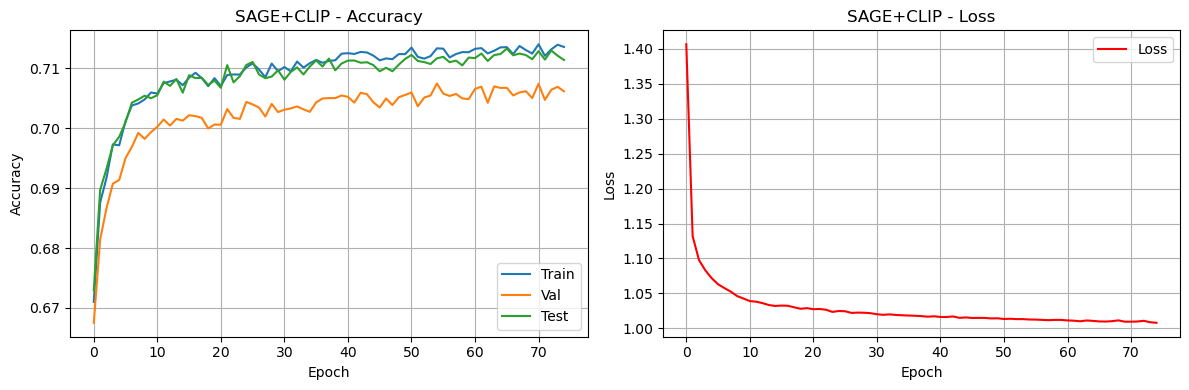

In [37]:
val_clip, test_clip = train(
    data, X_clip, in_channels=512, num_classes=num_classes,
    model_name='SAGE+CLIP', lr=1e-3
)

In [ ]:
val_dino, test_dino = train(
    data, X_dino, in_channels=768, num_classes=num_classes,
    model_name='SAGE+DINOv2', lr=1e-3
)

## Results summary

In [ ]:
import pandas as pd

results = pd.DataFrame([
    {'model': 'SAGE+ResNet50', 'val_acc': val_resnet, 'test_acc': test_resnet},
    {'model': 'SAGE+CLIP',     'val_acc': val_clip,   'test_acc': test_clip},
    {'model': 'SAGE+DINOv2',   'val_acc': val_dino,   'test_acc': test_dino},
])
print(results.to_string(index=False))